In [7]:
# ============================================================
# Subject: 23CSE301 - Lab Session 03/04
# All modular functions in a single code block
# AI TOOL USAGE: Generated with assistance from Claude (Anthropic).
# Function signatures/modularization were specified by the student;
# Claude generated the implementation bodies (Lab 04 requirement).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski as scipy_minkowski
import time


# ---------- A2: Encoding ----------
def label_encode(column_values):
    # AI-generated (Claude)
    unique_vals = sorted(set(column_values))
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    encoded = np.array([mapping[val] for val in column_values], dtype=int)
    return encoded, mapping


def one_hot_encode(column_values):
    # AI-generated (Claude)
    unique_vals = sorted(set(column_values))
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    n_rows = len(column_values)
    n_cats = len(unique_vals)
    encoded = np.zeros((n_rows, n_cats), dtype=int)
    for row_idx, val in enumerate(column_values):
        encoded[row_idx, mapping[val]] = 1
    return encoded, unique_vals


# ---------- A4: Minkowski distance ----------
def minkowski_distance(vector_a, vector_b, p):
    # AI-generated (Claude)
    vector_a = np.asarray(vector_a, dtype=float)
    vector_b = np.asarray(vector_b, dtype=float)
    if vector_a.shape != vector_b.shape:
        raise ValueError("Vectors must be the same shape")
    diff = np.abs(vector_a - vector_b)
    return np.sum(diff ** p) ** (1.0 / p)


# ---------- A7: Dot product & norm ----------
def dot_product(vector_a, vector_b):
    # AI-generated (Claude)
    vector_a = np.asarray(vector_a, dtype=float)
    vector_b = np.asarray(vector_b, dtype=float)
    if vector_a.shape != vector_b.shape:
        raise ValueError("Vectors must be the same shape")
    total = 0.0
    for a_val, b_val in zip(vector_a, vector_b):
        total += a_val * b_val
    return total


def euclidean_norm(vector):
    # AI-generated (Claude)
    vector = np.asarray(vector, dtype=float)
    return dot_product(vector, vector) ** 0.5


# ---------- A8: Mean, variance, std ----------
def compute_mean(data_matrix, axis=0):
    # AI-generated (Claude)
    data_matrix = np.asarray(data_matrix, dtype=float)
    n = data_matrix.shape[axis]
    return np.sum(data_matrix, axis=axis) / n


def compute_variance(data_matrix, axis=0):
    # AI-generated (Claude)
    data_matrix = np.asarray(data_matrix, dtype=float)
    mean_vals = compute_mean(data_matrix, axis=axis)
    n = data_matrix.shape[axis]
    if axis == 0:
        squared_diff = (data_matrix - mean_vals) ** 2
    else:
        squared_diff = (data_matrix - mean_vals.reshape(-1, 1)) ** 2
    return np.sum(squared_diff, axis=axis) / n


def compute_std(data_matrix, axis=0):
    # AI-generated (Claude)
    return np.sqrt(compute_variance(data_matrix, axis=axis))


# ---------- A11: K-means (own version, built from functions above) ----------
def initialize_centroids(data_matrix, k, random_state=None):
    # AI-generated (Claude)
    rng = np.random.default_rng(random_state)
    n_samples = data_matrix.shape[0]
    indices = rng.choice(n_samples, size=k, replace=False)
    return data_matrix[indices].copy()


def assign_clusters(data_matrix, centroids):
    # AI-generated (Claude)
    n_samples = data_matrix.shape[0]
    k = centroids.shape[0]
    distances = np.zeros((n_samples, k))
    for cluster_idx in range(k):
        for sample_idx in range(n_samples):
            distances[sample_idx, cluster_idx] = minkowski_distance(
                data_matrix[sample_idx], centroids[cluster_idx], p=2
            )
    return np.argmin(distances, axis=1)


def recompute_centroids(data_matrix, labels, k):
    # AI-generated (Claude)
    n_features = data_matrix.shape[1]
    new_centroids = np.zeros((k, n_features))
    for cluster_idx in range(k):
        members = data_matrix[labels == cluster_idx]
        if len(members) == 0:
            new_centroids[cluster_idx] = data_matrix[np.random.randint(0, data_matrix.shape[0])]
        else:
            new_centroids[cluster_idx] = compute_mean(members, axis=0)
    return new_centroids


def kmeans_own(data_matrix, k, max_iterations=100, tolerance=1e-6, random_state=None):
    # AI-generated (Claude)
    data_matrix = np.asarray(data_matrix, dtype=float)
    centroids = initialize_centroids(data_matrix, k, random_state=random_state)
    for iteration in range(max_iterations):
        labels = assign_clusters(data_matrix, centroids)
        new_centroids = recompute_centroids(data_matrix, labels, k)
        shift = np.sum(np.abs(new_centroids - centroids))
        centroids = new_centroids
        if shift < tolerance:
            return labels, centroids, iteration + 1
    return labels, centroids, max_iterations


# ---------- Lab 04: Second (vectorized) k-means for A3 performance comparison ----------
def kmeans_ai(data_matrix, k, max_iterations=100, tolerance=1e-6, random_state=None):
    # AI-generated (Claude) - uses numpy broadcasting instead of nested loops
    data_matrix = np.asarray(data_matrix, dtype=float)
    n_samples, n_features = data_matrix.shape
    rng = np.random.default_rng(random_state)
    init_idx = rng.choice(n_samples, size=k, replace=False)
    centroids = data_matrix[init_idx].copy()
    labels = np.zeros(n_samples, dtype=int)

    for iteration in range(max_iterations):
        diffs = data_matrix[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        sq_distances = np.sum(diffs ** 2, axis=2)
        labels = np.argmin(sq_distances, axis=1)

        new_centroids = np.empty_like(centroids)
        for cluster_idx in range(k):
            members = data_matrix[labels == cluster_idx]
            if members.shape[0] == 0:
                new_centroids[cluster_idx] = data_matrix[rng.integers(0, n_samples)]
            else:
                new_centroids[cluster_idx] = members.mean(axis=0)

        shift = np.sum(np.abs(new_centroids - centroids))
        centroids = new_centroids
        if shift < tolerance:
            return labels, centroids, iteration + 1

    return labels, centroids, max_iterations

Loaded marketing_campaign: (2240, 29)
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Label-encoded Education mapping: {'2n Cycle': 0,

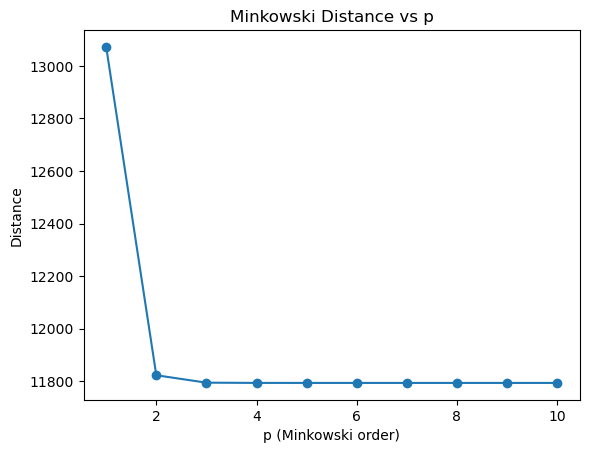


Dot product: own=2694360033.0000, numpy=2694360033.0000
Norm: own=58144.1275, numpy=58144.1275

Own mean:   [5.22472514e+04 4.90126354e+01 3.05091606e+02 2.63560469e+01
 1.66995939e+02 4.08528881e+00]
Numpy mean: [5.22472514e+04 4.90126354e+01 3.05091606e+02 2.63560469e+01
 1.66995939e+02 4.08528881e+00]
Own std:    [2.51673962e+04 2.89418193e+01 3.37251800e+02 3.97849367e+01
 2.24232662e+02 2.74033257e+00]
Numpy std:  [2.51673962e+04 2.89418193e+01 3.37251800e+02 3.97849367e+01
 2.24232662e+02 2.74033257e+00]

Income histogram counts: [1654  554    7    0    0    0    0    0    0    1]


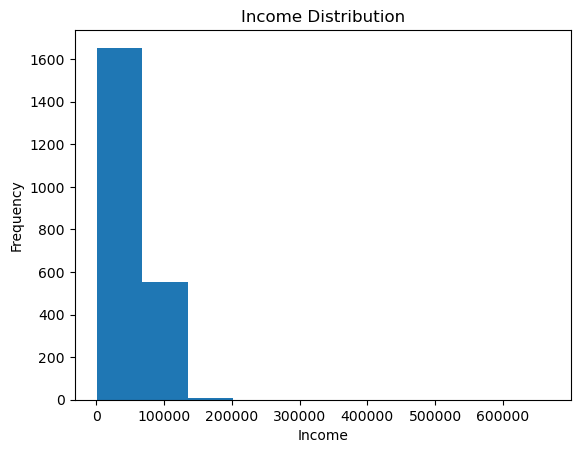


Own k-means:  4.9655s, 23 iterations
AI k-means:   0.0277s, 23 iterations
Speedup: 179.27x
Cluster sizes (own): [615 609 597 395]
Cluster sizes (AI):  [615 609 597 395]


In [11]:
# ============================================================
# Main program - all print statements live here (Lab 03 rule #2)
# ============================================================

# Upload Lab_Session_Data.xlsx to Colab first (left sidebar > Files > upload),
# or update the path if running locally.
df = pd.read_excel("C:/Users/Chigi/Downloads/Lab Session Data.xlsx", sheet_name="marketing_campaign")
print("Loaded marketing_campaign:", df.shape)
print(df.dtypes)
print()

# A2/A3: Encoding
edu_encoded, edu_map = label_encode(df["Education"].tolist())
print("Label-encoded Education mapping:", edu_map)

marital_onehot, marital_cats = one_hot_encode(df["Marital_Status"].tolist())
print("One-hot Marital_Status categories:", marital_cats)
print("One-hot shape:", marital_onehot.shape)
print()

# A4-A6: Minkowski distance
numeric_cols = ["Income", "Recency", "MntWines", "MntFruits", "MntMeatProducts", "NumWebPurchases"]
numeric_df = df[numeric_cols].dropna()
vec_a = numeric_df.iloc[0].values
vec_b = numeric_df.iloc[1].values

p_values = list(range(1, 11))
distances = [minkowski_distance(vec_a, vec_b, p) for p in p_values]
for p, d in zip(p_values, distances):
    print(f"p={p}: own={d:.4f}, scipy={scipy_minkowski(vec_a, vec_b, p):.4f}")

plt.figure()
plt.plot(p_values, distances, marker="o")
plt.xlabel("p (Minkowski order)")
plt.ylabel("Distance")
plt.title("Minkowski Distance vs p")
plt.show()
print()

# A7: Dot product & norm
print(f"Dot product: own={dot_product(vec_a, vec_b):.4f}, numpy={np.dot(vec_a, vec_b):.4f}")
print(f"Norm: own={euclidean_norm(vec_a):.4f}, numpy={np.linalg.norm(vec_a):.4f}")
print()

# A8/A9: Mean, variance, std
data_matrix = numeric_df.values
print("Own mean:  ", compute_mean(data_matrix, axis=0))
print("Numpy mean:", data_matrix.mean(axis=0))
print("Own std:   ", compute_std(data_matrix, axis=0))
print("Numpy std: ", data_matrix.std(axis=0))
print()

# A10: Histogram
feature = numeric_df["Income"].values
counts, bin_edges = np.histogram(feature, bins=10)
print("Income histogram counts:", counts)
plt.figure()
plt.hist(feature, bins=10)
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.title("Income Distribution")
plt.show()
print()

# A11 / Lab04 A3: K-means own vs AI, performance comparison
norm_features = (data_matrix - data_matrix.mean(axis=0)) / data_matrix.std(axis=0)
k = 4

start = time.perf_counter()
labels_own, centroids_own, iters_own = kmeans_own(norm_features, k=k, random_state=5)
time_own = time.perf_counter() - start

start = time.perf_counter()
labels_ai, centroids_ai, iters_ai = kmeans_ai(norm_features, k=k, random_state=5)
time_ai = time.perf_counter() - start

print(f"Own k-means:  {time_own:.4f}s, {iters_own} iterations")
print(f"AI k-means:   {time_ai:.4f}s, {iters_ai} iterations")
print(f"Speedup: {time_own / time_ai:.2f}x")
print("Cluster sizes (own):", np.bincount(labels_own))
print("Cluster sizes (AI): ", np.bincount(labels_ai))

In [13]:
# ============================================================
# Cell 3 - Unit tests (Lab 04, A2)
# "Generate unit test cases using AI tools for testing your modular
# functions. Use for both today's and last week's lab exercises."
# AI-generated (Claude), using Python's built-in unittest framework.
# ============================================================

import unittest


class TestEncoding(unittest.TestCase):
    def test_label_encode_basic(self):
        values = ["Basic", "PhD", "Basic", "Master"]
        encoded, mapping = label_encode(values)
        self.assertEqual(len(encoded), 4)
        self.assertEqual(encoded[0], encoded[2])
        self.assertEqual(len(mapping), 3)

    def test_one_hot_encode_shape_and_rowsum(self):
        values = ["Single", "Married", "Single", "Divorced"]
        encoded, categories = one_hot_encode(values)
        self.assertEqual(encoded.shape, (4, 3))
        self.assertTrue(np.all(encoded.sum(axis=1) == 1))

    def test_one_hot_encode_consistency_with_label_encode(self):
        values = ["A", "B", "A"]
        _, mapping = label_encode(values)
        encoded, categories = one_hot_encode(values)
        self.assertEqual(list(mapping.keys()), categories)


class TestMinkowskiDistance(unittest.TestCase):
    def test_manhattan_p1(self):
        self.assertAlmostEqual(minkowski_distance([1, 2, 3], [4, 6, 8], p=1), 12)

    def test_euclidean_p2(self):
        self.assertAlmostEqual(minkowski_distance([0, 0], [3, 4], p=2), 5.0)

    def test_matches_scipy(self):
        rng = np.random.default_rng(42)
        a = rng.random(10)
        b = rng.random(10)
        for p in range(1, 6):
            self.assertAlmostEqual(minkowski_distance(a, b, p), scipy_minkowski(a, b, p), places=6)

    def test_zero_distance_identical_vectors(self):
        a = [1, 2, 3]
        self.assertAlmostEqual(minkowski_distance(a, a, p=3), 0.0)

    def test_mismatched_shapes_raise(self):
        with self.assertRaises(ValueError):
            minkowski_distance([1, 2], [1, 2, 3], p=2)


class TestDotProductAndNorm(unittest.TestCase):
    def test_dot_product_matches_numpy(self):
        rng = np.random.default_rng(1)
        a = rng.random(15)
        b = rng.random(15)
        self.assertAlmostEqual(dot_product(a, b), float(np.dot(a, b)), places=8)

    def test_dot_product_orthogonal_vectors(self):
        self.assertAlmostEqual(dot_product([1, 0], [0, 1]), 0.0)

    def test_euclidean_norm_matches_numpy(self):
        rng = np.random.default_rng(2)
        a = rng.random(10)
        self.assertAlmostEqual(euclidean_norm(a), float(np.linalg.norm(a)), places=8)

    def test_euclidean_norm_unit_vector(self):
        self.assertAlmostEqual(euclidean_norm([1, 0, 0]), 1.0)


class TestMeanVarianceStd(unittest.TestCase):
    def setUp(self):
        self.data = np.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])

    def test_mean_matches_numpy(self):
        np.testing.assert_allclose(compute_mean(self.data, axis=0), self.data.mean(axis=0))

    def test_variance_matches_numpy(self):
        np.testing.assert_allclose(compute_variance(self.data, axis=0), self.data.var(axis=0))

    def test_std_matches_numpy(self):
        np.testing.assert_allclose(compute_std(self.data, axis=0), self.data.std(axis=0))

    def test_std_squared_equals_variance(self):
        variance = compute_variance(self.data, axis=0)
        std = compute_std(self.data, axis=0)
        np.testing.assert_allclose(std ** 2, variance)


class TestKMeans(unittest.TestCase):
    def setUp(self):
        rng = np.random.default_rng(0)
        cluster_0 = rng.normal(loc=[0, 0], scale=0.3, size=(20, 2))
        cluster_1 = rng.normal(loc=[10, 10], scale=0.3, size=(20, 2))
        cluster_2 = rng.normal(loc=[0, 10], scale=0.3, size=(20, 2))
        self.data = np.vstack([cluster_0, cluster_1, cluster_2])
        # random_state=5 gives a well-spread initial centroid draw; plain
        # Lloyd's k-means (no k-means++) is sensitive to bad initial draws.
        self.good_seed = 5

    def _check_three_clean_clusters(self, labels):
        self.assertEqual(len(np.unique(labels)), 3)
        for block_start in (0, 20, 40):
            block_labels = labels[block_start:block_start + 20]
            most_common_count = np.bincount(block_labels).max()
            self.assertGreaterEqual(most_common_count, 18)

    def test_kmeans_own_separates_blobs(self):
        labels, centroids, n_iter = kmeans_own(self.data, k=3, random_state=self.good_seed)
        self.assertEqual(centroids.shape, (3, 2))
        self._check_three_clean_clusters(labels)

    def test_kmeans_ai_separates_blobs(self):
        labels, centroids, n_iter = kmeans_ai(self.data, k=3, random_state=self.good_seed)
        self.assertEqual(centroids.shape, (3, 2))
        self._check_three_clean_clusters(labels)

    def test_kmeans_own_converges(self):
        _, _, n_iter = kmeans_own(self.data, k=3, max_iterations=50, random_state=1)
        self.assertLess(n_iter, 50)

    def test_kmeans_ai_converges(self):
        _, _, n_iter = kmeans_ai(self.data, k=3, max_iterations=50, random_state=1)
        self.assertLess(n_iter, 50)

    def test_both_versions_similar_inertia(self):
        labels_own, centroids_own, _ = kmeans_own(self.data, k=3, random_state=7)
        labels_ai, centroids_ai, _ = kmeans_ai(self.data, k=3, random_state=7)

        def inertia(data, labels, centroids):
            return sum(
                np.sum((data[labels == c] - centroids[c]) ** 2)
                for c in range(centroids.shape[0])
            )

        self.assertAlmostEqual(
            inertia(self.data, labels_own, centroids_own),
            inertia(self.data, labels_ai, centroids_ai),
            delta=1.0,
        )


# In a notebook, sys.argv confuses unittest's arg parser, so run it this way:
unittest.main(argv=[""], exit=False, verbosity=2)

test_dot_product_matches_numpy (__main__.TestDotProductAndNorm.test_dot_product_matches_numpy) ... ok
test_dot_product_orthogonal_vectors (__main__.TestDotProductAndNorm.test_dot_product_orthogonal_vectors) ... ok
test_euclidean_norm_matches_numpy (__main__.TestDotProductAndNorm.test_euclidean_norm_matches_numpy) ... ok
test_euclidean_norm_unit_vector (__main__.TestDotProductAndNorm.test_euclidean_norm_unit_vector) ... ok
test_label_encode_basic (__main__.TestEncoding.test_label_encode_basic) ... ok
test_one_hot_encode_consistency_with_label_encode (__main__.TestEncoding.test_one_hot_encode_consistency_with_label_encode) ... ok
test_one_hot_encode_shape_and_rowsum (__main__.TestEncoding.test_one_hot_encode_shape_and_rowsum) ... ok
test_both_versions_similar_inertia (__main__.TestKMeans.test_both_versions_similar_inertia) ... ok
test_kmeans_ai_converges (__main__.TestKMeans.test_kmeans_ai_converges) ... ok
test_kmeans_ai_separates_blobs (__main__.TestKMeans.test_kmeans_ai_separates_blob